In [1]:
import pandas as pd
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

In [2]:
commuter_data = pd.read_csv("2021_commuter_data/commuter_matrix.csv", index_col=0)
commuter_matrix = commuter_data.values
patch_ids = commuter_data.index.values
population_sizes = commuter_matrix.sum(axis=1)

In [55]:
def calc_ngm(beta, gamma, psi):
    pop_ratios = np.zeros(shape=population_sizes.shape)
    pop_ratios[population_sizes != 0] = 1/population_sizes[population_sizes != 0]
    ngm = np.dot(commuter_matrix.T, np.diag(pop_ratios)) *(1-psi)/gamma
    np.fill_diagonal(ngm, beta*psi/gamma)
    return max(eigh(ngm, eigvals_only=True))


In [56]:
calc_ngm(1.3,0.3, 0.2)

1.991165261675475

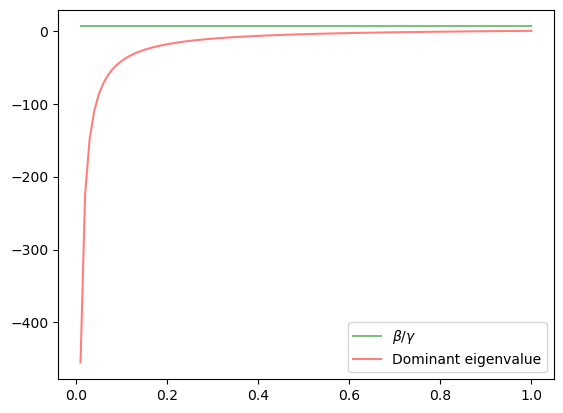

In [57]:
b,g = 1.8, 0.3
p_range = np.linspace(0.01, 1 , 100)
ngm_range = [(calc_ngm(b,g,p) - b/g)/p for p in p_range]

plt.plot(p_range, np.repeat(b/g, p_range.size),label=r"$\beta/\gamma$", alpha=0.5, c='g')
plt.plot(p_range, ngm_range, label="Dominant eigenvalue", alpha=0.5, c='r')
plt.legend()
plt.show()